In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/loan_data.csv")
df.head()

,Customer_ID,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,LP216038,Female,No,2,Graduate,No,4809.0,3329.0,3650.0,180,Rural,Yes
1,LP288956,Female,Yes,1,Graduate,No,3358.0,NaN,6680.0,360,Rural,No
2,LP153364,Female,Yes,1,Graduate,No,9873.0,1649.0,NaN,360,Semiurban,No
3,LP945891,Male,No,0,Graduate,Yes,11665.0,4378.0,8366.0,360,Rural,Yes
4,LP425056,Female,No,1,Graduate,No,5890.0,1523.0,8741.0,180,Urban,Yes


### Task 1: Dataset Understanding and Exploration

In [3]:
def display_rows_cols():
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")
    
display_rows_cols()

Number of rows: 10000
Number of columns: 12


In [4]:
df.shape

(10000, 12)

In [5]:
df.head()

,Customer_ID,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
0,LP216038,Female,No,2,Graduate,No,4809.0,3329.0,3650.0,180,Rural,Yes
1,LP288956,Female,Yes,1,Graduate,No,3358.0,NaN,6680.0,360,Rural,No
2,LP153364,Female,Yes,1,Graduate,No,9873.0,1649.0,NaN,360,Semiurban,No
3,LP945891,Male,No,0,Graduate,Yes,11665.0,4378.0,8366.0,360,Rural,Yes
4,LP425056,Female,No,1,Graduate,No,5890.0,1523.0,8741.0,180,Urban,Yes


In [6]:
df.tail()

,Customer_ID,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
9995,LP693571,Male,Yes,3+,Graduate,Yes,8998.0,2137.0,2487.0,360,Semiurban,Yes
9996,LP193182,Female,No,1,Graduate,Yes,7186.0,NaN,5380.0,360,Rural,Yes
9997,LP668937,Male,No,0,Not Graduate,No,2778.0,678.0,2794.0,180,Rural,Yes
9998,LP447580,Male,No,3+,Graduate,Yes,4746.0,1172.0,NaN,180,Semiurban,No
9999,LP146890,Female,Yes,1,Graduate,No,NaN,1839.0,6084.0,360,Rural,Yes


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           10000 non-null  str    
 1   Gender                10000 non-null  str    
 2   Marital_Status        10000 non-null  str    
 3   Number_of_Dependents  10000 non-null  str    
 4   Education             10000 non-null  str    
 5   Loan_Status           10000 non-null  str    
 6   Annual_Income         9000 non-null   float64
 7   Credit_Score          8979 non-null   float64
 8   Loan_Amount           8987 non-null   float64
 9   Term                  10000 non-null  int64  
 10  Property_Area         10000 non-null  str    
 11  Loan_Approval         10000 non-null  str    
dtypes: float64(3), int64(1), str(8)
memory usage: 937.6 KB


Information of the dataset including number of rows, columns, columns' name, data type, size

In [8]:
df.describe()

,Annual_Income,Credit_Score,Loan_Amount,Term
count,9000.000000,8979.000000,8987.000000,10000.000000
mean,6740.199667,2622.278316,4995.397797,269.334000
std,3019.882729,1381.345574,2860.382446,90.002036
min,1500.000000,0.000000,0.000000,180.000000
25%,4181.000000,1437.000000,2529.500000,180.000000
50%,6669.000000,2627.000000,5021.000000,180.000000
75%,9333.000000,3800.000000,7460.500000,360.000000
max,12000.000000,5000.000000,10000.000000,360.000000


Summary statistics of those columns having float and int data type.

In [9]:
df.dtypes

Customer_ID                 str
Gender                      str
Marital_Status              str
Number_of_Dependents        str
Education                   str
Loan_Status                 str
Annual_Income           float64
Credit_Score            float64
Loan_Amount             float64
Term                      int64
Property_Area               str
Loan_Approval               str
dtype: object

Above information exhibit ***'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Term'*** columns are *string* data type, ***'Annual_Income', 'Credit_Score', 'Loan_Amount'*** are *float* data type, and ***'Term'*** is the *int* data type.

In [10]:
# categorial features
cat_cols = df.select_dtypes(include=['object', 'category']).columns.to_list()
cat_cols

['Customer_ID',
 'Gender',
 'Marital_Status',
 'Number_of_Dependents',
 'Education',
 'Loan_Status',
 'Property_Area',
 'Loan_Approval']

In [11]:
# numerical features
num_cols = df.select_dtypes(include=[float, int]).columns.to_list()
num_cols

['Annual_Income', 'Credit_Score', 'Loan_Amount', 'Term']

### Task 2: Descriptive Statistical Analysis

In [12]:
df.describe()

,Annual_Income,Credit_Score,Loan_Amount,Term
count,9000.000000,8979.000000,8987.000000,10000.000000
mean,6740.199667,2622.278316,4995.397797,269.334000
std,3019.882729,1381.345574,2860.382446,90.002036
min,1500.000000,0.000000,0.000000,180.000000
25%,4181.000000,1437.000000,2529.500000,180.000000
50%,6669.000000,2627.000000,5021.000000,180.000000
75%,9333.000000,3800.000000,7460.500000,360.000000
max,12000.000000,5000.000000,10000.000000,360.000000


In [13]:
def line():
    print("\n" + 100*"=" + "\n")

In [14]:
for col in num_cols:
    print(col)
    print(f"Mean: {df[col].mean()}")
    print(f"Median: {df[col].median()}")
    
    print("Mode:")
    print(df[col].mode())
    print(f"Maximum: {df[col].max()}")
    print(f"Minimum: {df[col].min()}")
    print(f"Range: {df[col].max() - df[col].min()}")

    print(f"Variance: {df[col].var()}")
    print(f"Standard Deviation: {df[col].std()}")
    print("Quartiles")
    print(f"25th percentile: {df[col].quantile(0.25)}")
    print(f"50th percentile: {df[col].quantile(0.50)}")
    print(f"75th percentile: {df[col].quantile(0.75)}")
    
    line()
    
    

Annual_Income
Mean: 6740.199666666666
Median: 6669.0
Mode:
0    3016.0
1    5036.0
Name: Annual_Income, dtype: float64
Maximum: 12000.0
Minimum: 1500.0
Range: 10500.0
Variance: 9119691.697766308
Standard Deviation: 3019.8827291413663
Quartiles
25th percentile: 4181.0
50th percentile: 6669.0
75th percentile: 9333.0


Credit_Score
Mean: 2622.278316070832
Median: 2627.0
Mode:
0    1303.0
1    1723.0
2    2137.0
3    4266.0
Name: Credit_Score, dtype: float64
Maximum: 5000.0
Minimum: 0.0
Range: 5000.0
Variance: 1908115.5956213118
Standard Deviation: 1381.3455742938881
Quartiles
25th percentile: 1437.0
50th percentile: 2627.0
75th percentile: 3800.0


Loan_Amount
Mean: 4995.397796817625
Median: 5021.0
Mode:
0     261.0
1    1861.0
2    1874.0
3    2895.0
4    4979.0
5    8499.0
Name: Loan_Amount, dtype: float64
Maximum: 10000.0
Minimum: 0.0
Range: 10000.0
Variance: 8181787.73880218
Standard Deviation: 2860.3824462477355
Quartiles
25th percentile: 2529.5
50th percentile: 5021.0
75th percentil

### Task 3: Exploratory Data Analysis (EDA)

##### 1. Duplicate values analysis

In [15]:
df.duplicated().sum()

np.int64(0)

0 means the dataset does not have duplicate values

##### 2. Missing values analysis

In [16]:
df.isnull().sum()

Customer_ID                0
Gender                     0
Marital_Status             0
Number_of_Dependents       0
Education                  0
Loan_Status                0
Annual_Income           1000
Credit_Score            1021
Loan_Amount             1013
Term                       0
Property_Area              0
Loan_Approval              0
dtype: int64

In [17]:
# columns having missing values
missing_value_cols = df.columns[df.isnull().any()].to_list()
missing_value_cols

['Annual_Income', 'Credit_Score', 'Loan_Amount']

***'Annual_Income', 'Credit_Score', 'Loan_Amount'*** columns have missing values

In [18]:
# finding how much proportion of columns have missing values
for mvc in missing_value_cols:
    print(f"{mvc} column has {round(df[mvc].isnull().mean() * 100, 2)}% missing values.")

Annual_Income column has 10.0% missing values.
Credit_Score column has 10.21% missing values.
Loan_Amount column has 10.13% missing values.


##### 3. Handling inconsistent data

In [19]:
for col in cat_cols:
    print(col)
    df[col] = df[col].str.strip()
    print(df[col].sort_values().unique())
    
    line()
    
    

Customer_ID
<StringArray>
['LP100014', 'LP100194', 'LP100391', 'LP100400', 'LP100422', 'LP100458',
 'LP100481', 'LP101198', 'LP101209', 'LP101261',
 ...
 'LP999295', 'LP999326', 'LP999464', 'LP999487', 'LP999523', 'LP999553',
 'LP999679', 'LP999760', 'LP999769', 'LP999975']
Length: 9940, dtype: str


Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


Marital_Status
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


Number_of_Dependents
<StringArray>
['0', '1', '2', '3+']
Length: 4, dtype: str


Education
<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str


Loan_Status
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


Property_Area
<StringArray>
['Rural', 'Semiurban', 'Urban']
Length: 3, dtype: str


Loan_Approval
<StringArray>
['No', 'Yes']
Length: 2, dtype: str




All categorical features have consistent string values except **Number_of_Dependents** column, which has categorical data i.e ['0', '1', '2', '3+'], and needs to be int data type.

In [20]:
# repalce '3+' by 3 and data conversion into int
df["Number_of_Dependents"] = df["Number_of_Dependents"].replace({'3+': 3}).astype(int)

In [21]:
df["Number_of_Dependents"].info()

<class 'pandas.Series'>
RangeIndex: 10000 entries, 0 to 9999
Series name: Number_of_Dependents
Non-Null Count  Dtype
--------------  -----
10000 non-null  int64
dtypes: int64(1)
memory usage: 78.3 KB


In [22]:
df["Number_of_Dependents"].value_counts()

Number_of_Dependents
2    2541
1    2531
0    2478
3    2450
Name: count, dtype: int64

##### 4. Outlier detection using Skewness and Kurtosis

In [23]:
print(f"Skewness: \n{df[num_cols].skew()}")
line()
print(f"Kurtosis: \n{df[num_cols].kurt()}")

Skewness: 
Annual_Income    0.024273
Credit_Score    -0.020921
Loan_Amount      0.000941
Term             0.014803
dtype: float64


Kurtosis: 
Annual_Income   -1.194190
Credit_Score    -1.153786
Loan_Amount     -1.172995
Term            -2.000181
dtype: float64


Note: 

**Skewness** measures the asymmetry of a distribution.

Skewnesss value between -0.5 and 0.5 indicates that the data is fairly symmetrical so, the values of above numerical features are close to 0, which means values are distributed evenly around the center.

**Kurtosis** measures whether the data is heavy-tailed (lots of outliers) or light-tailed (few outliers) compared to a normal distribution. A standard normal distribution has an excess kurtosis of 0. Negative kurtosis indicates a "Platykurtic" distribution—meaning it is flatter and has thinner tails than a normal bell curve.

Here, the data does not have extreme outliers, which forms a wide, flat plateau rather than a sharp peak.


Note: *The given dataset has perfectly zero skewness and negative kurtosis because the data is artificially generated (synthetic). Real-world financial data is almost always highly right-skewed (most people have average incomes, a few have massive incomes).*


Using a standard IQR calcualtion to check whether the dataset has outliers or not.

In [24]:
# checking outlier in Loan_Amount column
Q1 = df["Loan_Amount"].quantile(0.25)
Q3 = df["Loan_Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)


outliers = df[(df["Loan_Amount"] < lower_bound) | (df["Loan_Amount"] > upper_bound)]

print(f"Number of sever outliers in 'Loan_Amount': {len(outliers)}")

Number of sever outliers in 'Loan_Amount': 0


As data is synthetic, which has 0 outliers in **'Loan_Amount'** column.

In [25]:
# customer IDs are unique identifiers, which has no role for predicition so dropping it
df.drop(columns=["Customer_ID"], inplace=True)

In [26]:
df.columns

Index(['Gender', 'Marital_Status', 'Number_of_Dependents', 'Education',
       'Loan_Status', 'Annual_Income', 'Credit_Score', 'Loan_Amount', 'Term',
       'Property_Area', 'Loan_Approval'],
      dtype='str')

In [27]:
df.groupby("Education")["Loan_Amount"].mean().round(2)

Education
Graduate        4995.5
Not Graduate    4995.3
Name: Loan_Amount, dtype: float64

Average loan amount received by different education levels.

In [28]:
df.sample(8)

,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
7865,Female,No,3,Graduate,No,4181.0,NaN,7325.0,180,Semiurban,Yes
4404,Male,Yes,2,Not Graduate,Yes,9571.0,4330.0,2670.0,180,Urban,Yes
3503,Male,No,0,Not Graduate,No,3956.0,1551.0,4872.0,360,Urban,No
6508,Female,Yes,0,Not Graduate,Yes,11799.0,1294.0,529.0,180,Semiurban,Yes
103,Male,No,3,Graduate,Yes,2080.0,NaN,NaN,180,Rural,Yes
8357,Female,No,1,Graduate,No,8532.0,NaN,NaN,180,Rural,No
4975,Male,Yes,3,Graduate,No,3265.0,2125.0,4663.0,360,Urban,No
6284,Female,No,0,Not Graduate,Yes,5323.0,1170.0,1916.0,180,Urban,No


In [29]:
df.loc[(df["Annual_Income"] > 5000) & (df["Loan_Approval"] == "Yes")]

,Gender,Marital_Status,Number_of_Dependents,Education,Loan_Status,Annual_Income,Credit_Score,Loan_Amount,Term,Property_Area,Loan_Approval
3,Male,No,0,Graduate,Yes,11665.0,4378.0,8366.0,360,Rural,Yes
4,Female,No,1,Graduate,No,5890.0,1523.0,8741.0,180,Urban,Yes
9,Male,No,2,Not Graduate,Yes,6810.0,1887.0,1176.0,180,Semiurban,Yes
10,Male,Yes,1,Graduate,No,7912.0,1531.0,9212.0,360,Semiurban,Yes
17,Male,No,3,Graduate,No,10508.0,NaN,8169.0,360,Urban,Yes
...,...,...,...,...,...,...,...,...,...,...,...
9980,Female,No,1,Not Graduate,No,9391.0,1950.0,8011.0,360,Urban,Yes
9987,Female,Yes,0,Graduate,No,5691.0,4913.0,9028.0,180,Rural,Yes
9993,Male,Yes,0,Not Graduate,No,10246.0,336.0,6525.0,360,Semiurban,Yes
9995,Male,Yes,3,Graduate,Yes,8998.0,2137.0,2487.0,360,Semiurban,Yes


Above rows are those data whose has annual income > 5000 and loan approval is acceptable.

In [30]:
num_approval = df.loc[(df["Annual_Income"] > 5000) & (df["Loan_Approval"] == "Yes")]
print(f"Number of customers whose annual income > 5000 and loan is approved: {len(num_approval)}")

Number of customers whose annual income > 5000 and loan is approved: 3020


Data Visualization

In [31]:
import dash
from dash import dcc, html
import plotly.express as px

app = dash.Dash(__name__)

numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
corr_matrix = numeric_df.corr()

fig1 = px.imshow(corr_matrix, 
                 text_auto=".2f", 
                 aspect="auto",
                 color_continuous_scale='RdBu_r',
                 title="Correlation Heatmap"
                 )

fig2 = px.histogram(df, 
                    x="Annual_Income", 
                    nbins=30, 
                    color_discrete_sequence=['#3498db'],
                    title="Uniform Distribution of Annual Income")
fig2.update_layout(bargap=0.1) 

fig3 = px.histogram(df, 
                    x="Education", 
                    color="Loan_Approval", 
                    barmode="group",
                    color_discrete_sequence=['#e74c3c', '#2ecc71'],
                    title="Loan Approval Rates by Education Level"
                    )
fig4 = px.box(df, 
              x="Property_Area", 
              y="Credit_Score", 
              color="Property_Area",
              title="Credit Score Spread Across Property Areas")

app.layout = html.Div(style={'fontFamily': 'Arial, sans-serif', 'padding': '20px'}, children=[
    html.H1("Banking Loan Approval - Exploratory Dashboard", style={'textAlign': 'center', 'color': 'white'}),
    html.P("Hover over the charts to interact with the data.", style={'textAlign': 'center', 'color': 'white'}),
    
    html.Div(style={'display': 'flex', 'flexDirection': 'row', 'gap': '20px', 'marginBottom': '20px'}, children=[
        dcc.Graph(figure=fig1, style={'flex': '1'}),
        dcc.Graph(figure=fig2, style={'flex': '1'})
    ]),
    
    html.Div(style={'display': 'flex', 'flexDirection': 'row', 'gap': '20px'}, children=[
        dcc.Graph(figure=fig3, style={'flex': '1'}),
        dcc.Graph(figure=fig4, style={'flex': '1'})
    ])
])

if __name__ == '__main__':
    app.run(jupyter_mode="inline")

### Task 4: Data Preprocessing

##### 1. Handling missing values

All missing values are filled by median value.

In [32]:
# filling NANs values by respective median value
for col in missing_value_cols:
    median_val = df[col].median()
    # median value
    print(f'{col} median: {median_val}')
    
    # filling NaN by median
    df[col] = df[col].fillna(median_val)
    
    

Annual_Income median: 6669.0
Credit_Score median: 2627.0
Loan_Amount median: 5021.0


In [33]:
# after imputation
df.isnull().sum()

Gender                  0
Marital_Status          0
Number_of_Dependents    0
Education               0
Loan_Status             0
Annual_Income           0
Credit_Score            0
Loan_Amount             0
Term                    0
Property_Area           0
Loan_Approval           0
dtype: int64

In [34]:
# saving clean data
df.to_csv("../data/clean_loan_dataset.csv")

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Gender                10000 non-null  str    
 1   Marital_Status        10000 non-null  str    
 2   Number_of_Dependents  10000 non-null  int64  
 3   Education             10000 non-null  str    
 4   Loan_Status           10000 non-null  str    
 5   Annual_Income         10000 non-null  float64
 6   Credit_Score          10000 non-null  float64
 7   Loan_Amount           10000 non-null  float64
 8   Term                  10000 non-null  int64  
 9   Property_Area         10000 non-null  str    
 10  Loan_Approval         10000 non-null  str    
dtypes: float64(3), int64(2), str(6)
memory usage: 859.5 KB


In [36]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.to_list()
cat_cols

['Gender',
 'Marital_Status',
 'Education',
 'Loan_Status',
 'Property_Area',
 'Loan_Approval']

In [37]:
for col in cat_cols:
    print(col)
    print(df[col].unique())
    line()

Gender
<StringArray>
['Female', 'Male']
Length: 2, dtype: str


Marital_Status
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


Education
<StringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str


Loan_Status
<StringArray>
['No', 'Yes']
Length: 2, dtype: str


Property_Area
<StringArray>
['Rural', 'Semiurban', 'Urban']
Length: 3, dtype: str


Loan_Approval
<StringArray>
['Yes', 'No']
Length: 2, dtype: str




##### 2. Data Encoding

Note: 

- Using **Label Encoding** for 'Education' only becuase it is **ordinal data*, which comes in order form.
- Using **One-Hot Encoding** for 'Gender', 'Loan_Status', 'Property_Area', and 'Marital_Status' because they are **nominal data**, but not in 'Loan_Approval' because it is target value.

In [38]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [39]:
label_encoder = LabelEncoder()

df["Education"] = label_encoder.fit_transform(df["Education"])

In [40]:
df["Education"].unique()

array([0, 1])

In [41]:
cols_for_ohe = ["Gender", "Loan_Status", "Property_Area", "Marital_Status"]

In [42]:
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='error')

fitted_cols_for_ohe = ohe.fit_transform(df[cols_for_ohe])

In [43]:
fitted_cols_for_ohe

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(10000, 5))

In [44]:
df_encoded = pd.DataFrame(
    fitted_cols_for_ohe,
    columns=ohe.get_feature_names_out(cols_for_ohe),
    index=df.index
)

df_encoded.head()

,Gender_Male,Loan_Status_Yes,Property_Area_Semiurban,Property_Area_Urban,Marital_Status_Yes
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,1.0
3,1.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,1.0,0.0


In [45]:
# concatenating the encoded features and removing original 'Nominal data' i.e ["Gender", "Loan_Status", "Property_Area", "Marital_Status"]

df_final = pd.concat([df.drop(columns=cols_for_ohe), df_encoded],axis=1)

df_final.head()

,Number_of_Dependents,Education,Annual_Income,Credit_Score,Loan_Amount,Term,Loan_Approval,Gender_Male,Loan_Status_Yes,Property_Area_Semiurban,Property_Area_Urban,Marital_Status_Yes
0,2,0,4809.0,3329.0,3650.0,180,Yes,0.0,0.0,0.0,0.0,0.0
1,1,0,3358.0,2627.0,6680.0,360,No,0.0,0.0,0.0,0.0,1.0
2,1,0,9873.0,1649.0,5021.0,360,No,0.0,0.0,1.0,0.0,1.0
3,0,0,11665.0,4378.0,8366.0,360,Yes,1.0,1.0,0.0,0.0,0.0
4,1,0,5890.0,1523.0,8741.0,180,Yes,0.0,0.0,0.0,1.0,0.0


##### 3. Data Splitting

Data is splitted into training and testing sets 

In [46]:
from sklearn.model_selection import train_test_split

In [47]:
df_final.columns

Index(['Number_of_Dependents', 'Education', 'Annual_Income', 'Credit_Score',
       'Loan_Amount', 'Term', 'Loan_Approval', 'Gender_Male',
       'Loan_Status_Yes', 'Property_Area_Semiurban', 'Property_Area_Urban',
       'Marital_Status_Yes'],
      dtype='str')

In [48]:
X = df_final.drop(columns=["Loan_Approval"])
y = df_final["Loan_Approval"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [50]:
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (8000, 11)
Testing data shape: (2000, 11)


##### 4. Scaling/Normalization

Note: Normalization is done after splitting data into train and test to prevent from "data leakage" from the testing set into the training set

In [51]:
from sklearn.preprocessing import MinMaxScaler

In [52]:
# using MinMax scaler
scaler = MinMaxScaler()

In [53]:
num_cols

['Annual_Income', 'Credit_Score', 'Loan_Amount', 'Term']

In [54]:
# scaling only to numerical values
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.fit_transform(X_test[num_cols])

In [55]:
print("Min and Max values for Annual_Income in Training Data:")
print(f"Min: {X_train['Annual_Income'].min()}, Max: {X_train['Annual_Income'].max()}")

Min and Max values for Annual_Income in Training Data:
Min: 0.0, Max: 1.0


In [56]:
X_train.sample(6)

,Number_of_Dependents,Education,Annual_Income,Credit_Score,Loan_Amount,Term,Gender_Male,Loan_Status_Yes,Property_Area_Semiurban,Property_Area_Urban,Marital_Status_Yes
2500,3,0,0.476667,0.9954,0.535954,0.0,1.0,0.0,1.0,0.0,1.0
6193,0,1,0.849524,0.3694,0.502150,0.0,0.0,0.0,1.0,0.0,0.0
1235,3,1,0.276857,0.9882,0.964496,0.0,0.0,1.0,0.0,1.0,0.0
8741,3,0,0.327048,0.7600,0.502150,1.0,0.0,1.0,0.0,0.0,1.0
1866,2,1,0.727429,0.5836,0.748675,1.0,0.0,0.0,0.0,0.0,1.0
6864,0,0,0.643429,0.9422,0.218122,0.0,1.0,1.0,0.0,0.0,1.0


##### Task 5: Feature Engineering 

Correlations for numerical features

In [57]:
corr = X_train[num_cols].corr()
corr

,Annual_Income,Credit_Score,Loan_Amount,Term
Annual_Income,1.000000,-0.002075,-0.001423,-0.001755
Credit_Score,-0.002075,1.000000,0.000815,-0.001925
Loan_Amount,-0.001423,0.000815,1.000000,-0.004102
Term,-0.001755,-0.001925,-0.004102,1.000000


Chi-square test for categorial features

In [58]:
from sklearn.feature_selection import chi2

In [59]:
cat_cols = [col for col in X_train.columns if col not in num_cols]
cat_cols

['Number_of_Dependents',
 'Education',
 'Gender_Male',
 'Loan_Status_Yes',
 'Property_Area_Semiurban',
 'Property_Area_Urban',
 'Marital_Status_Yes']

In [60]:
chi_scores, p_values = chi2(X_train[cat_cols], y_train)

In [61]:
chi2_results = pd.DataFrame({
    'Feature': cat_cols,
    'Chi2_Score': chi_scores,
    'P_Value': p_values
})


chi2_results = chi2_results.sort_values(by='P_Value')
chi2_results

,Feature,Chi2_Score,P_Value
3,Loan_Status_Yes,1.015374,0.313619
0,Number_of_Dependents,0.686189,0.407464
6,Marital_Status_Yes,0.521707,0.470115
1,Education,0.225260,0.635061
5,Property_Area_Urban,0.097427,0.754939
2,Gender_Male,0.085106,0.770494
4,Property_Area_Semiurban,0.051361,0.820712


In a Chi-Square test, the Null Hypothesis assumes that a specific feature (like Education) and the target variable (Loan_Approval) are completely independent of one another.

- The P-Value represents the probability that this Null Hypothesis is correct.

- The Industry Standard: A threshold of 0.05.

- P-Value < 0.05: The feature is statistically significant. It affects the outcome.

- P-Value > 0.05: The feature is statistically independent. It has no predictive power.

However, looking at the results, every single categorical feature has a P-Value massively higher than 0.05 (ranging from 0.31 to 0.82). This means that statistically, whether a person is a Graduate, Urban, Male, or Married has absolutely zero mathematical impact on whether their loan gets approved.

##### Task 6: Machine Learning Model Development

In [62]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [63]:
nb = GaussianNB()

In [64]:
nb.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[3947.,4053.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.49,0.51]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[<U3](2,)","['No','Yes']"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1.238e-09
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](11,)","['Number_of_Dependents','Education','Annual_Income',..., 'Property_Area_Semiurban','Property_Area_Urban','Marital_Status_Yes']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,11
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 11)","[[1.51,0.5 ,0.5 ,...,0.34,0.33,0.5 ], [1.49,0.51,0.5 ,...,0.34,0.33,0.51]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 11)","[[1.22,0.25,0.08,...,0.22,0.22,0.25], [1.25,0.25,0.07,...,0.22,0.22,0.25]]"


In [65]:
nb.score(X_test, y_test)

0.507

In [66]:
y_hat = nb.predict(X_test)


In [67]:
print(f"Accuracy score: {accuracy_score(y_true=y_test, y_pred=y_hat)}")

Accuracy score: 0.507


In [68]:
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest Classifier": RandomForestClassifier()
}

In [69]:
results = []
for name, model in models.items():
    # training the model
    model.fit(X_train, y_train)
    
    # r_square value / accuracy score
    r2_val = model.score(X_test, y_test)
    
    # append the model name, and accuracy score
    results.append({"model": name, "accuracy": r2_val})
    
    print(f"{model} r-squared value: {r2_val}")
    line()

GaussianNB() r-squared value: 0.507


LogisticRegression() r-squared value: 0.51


RandomForestClassifier() r-squared value: 0.4845




In [70]:
comparison_df = pd.DataFrame(results).sort_values(by="accuracy", ascending=False)
comparison_df

,model,accuracy
1,Logistic Regression,0.5100
0,Naive Bayes,0.5070
2,Random Forest Classifier,0.4845


In [71]:
comparison_df["accuracy"] = (comparison_df["accuracy"] * 100).round(2).astype(str) + "%"
comparison_df

,model,accuracy
1,Logistic Regression,51.0%
0,Naive Bayes,50.7%
2,Random Forest Classifier,48.45%


In [72]:
best_model_name = comparison_df.iloc[0]["model"]
best_accuracy = comparison_df.iloc[0]["accuracy"]

print(f"Best Performing Model: {best_model_name} with an accuracy of {best_accuracy}")

Best Performing Model: Logistic Regression with an accuracy of 51.0%


##### Task 7: Model Validation and Performance Evaluation 

In [73]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [74]:
best_model = models["Logistic Regression"]
y_pred = best_model.predict(X_test)


In [75]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[374, 618],
       [362, 646]])

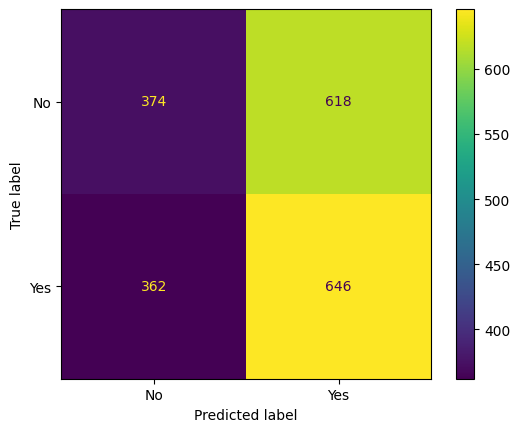

In [76]:
dis = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
dis.plot()

In [77]:
report = classification_report(y_test, y_pred, target_names=['Reject (0)', 'Approve (1)'])
print(report)

              precision    recall  f1-score   support

  Reject (0)       0.51      0.38      0.43       992
 Approve (1)       0.51      0.64      0.57      1008

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.51      0.51      0.50      2000



##### Task 8: Model Deployment

In [78]:
import pickle


In [ ]:
# saving the trained best model
pickle.dump(best_model, open('model.pkl', 'wb'))